SMS spam detection using BERT and multi-graph convolutional networks

In [ ]:
import os  # to get keys from env file 

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  BERT-G3CN  |  SMS Spam Detection                                ║
# ║  Cell 1 — Environment Setup                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Kaggle: install missing packages ──────────────────────────────
# !pip install -q transformers==4.40.0 spacy
# !python -m spacy download en_core_web_sm -q 

import os, gc, json, random, time, warnings
from collections import Counter, defaultdict

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader     
from torch.optim import AdamW 

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, confusion_matrix, classification_report 
)

import transformers
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup  
import spacy

# ── Silence noisy library output ──────────────────────────────────
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false" 
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
transformers.logging.set_verbosity_error()

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED) 
torch.manual_seed(SEED)  
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")   

# ── spaCy ─────────────────────────────────────────────────────────
try:
    NLP      = spacy.load("en_core_web_sm", disable=["ner"])
    NLP_FULL = spacy.load("en_core_web_sm")
except OSError:
    os.system("python -m spacy download en_core_web_sm -q")
    NLP      = spacy.load("en_core_web_sm", disable=["ner"])
    NLP_FULL = spacy.load("en_core_web_sm")

# ── Confirmation ──────────────────────────────────────────────────
print("Setup complete.")
print(f"  Device : {DEVICE}" + (f"  ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
print(f"  PyTorch  {torch.__version__}  |  Transformers  {transformers.__version__}")

Setup complete.
  Device : cuda  (Tesla T4)
  PyTorch  2.10.0+cu128  |  Transformers  5.0.0


In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 2 — Core Definitions                                      ║
# ║  Vocabulary, graphs, model, dataset, train/eval helpers.        ║
# ║  Must run before any experiment cell.                           ║
# ╚══════════════════════════════════════════════════════════════════╝


# ══════════════════════════════════════════════════════════════════
# 2.1  Data helpers
# ══════════════════════════════════════════════════════════════════

def load_uci(path):
    df = pd.read_csv(path, sep="\t", header=None, names=["label_str", "message"])
    df["label"] = (df["label_str"].str.strip().str.lower() == "spam").astype(int)
    return df[["message", "label"]].dropna().reset_index(drop=True)


def load_exais(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"Message": "message", "Spam": "label"})
    df["label"] = df["label"].astype(int)
    return df[["message", "label"]].dropna().reset_index(drop=True)


def split_data(texts, labels, test_size, val_frac, seed=SEED):
    tr_va, te, tr_va_l, te_l = train_test_split(
        texts, labels, test_size=test_size,
        random_state=seed, stratify=labels)
    tr, va, tr_l, va_l = train_test_split(
        tr_va, tr_va_l,
        test_size=round(val_frac / (1.0 - test_size), 4), 
        random_state=seed, stratify=tr_va_l)
    return tr, va, te, tr_l, va_l, te_l


# ══════════════════════════════════════════════════════════════════
# 2.2  Vocabulary
# ══════════════════════════════════════════════════════════════════

def build_vocabulary(texts, min_freq=2):
    counts = Counter(
        tok.text.lower()
        for txt in texts
        for tok in NLP(str(txt))
        if not tok.is_punct and not tok.is_space
    )
    vocab, idx = {}, 0
    for w, c in counts.items():
        if c >= min_freq:
            vocab[w] = idx
            idx += 1
    return vocab


# ══════════════════════════════════════════════════════════════════
# 2.3  Graph builders  (paper §3.2)
# ══════════════════════════════════════════════════════════════════

def _sym_norm(A):
    deg        = A.sum(1) + 1e-9
    d_inv_sqrt = 1.0 / np.sqrt(deg)
    return ((A * d_inv_sqrt[:, None]) * d_inv_sqrt[None, :]).astype(np.float32)


def build_cooccurrence(texts, vocab, window=5):
    V  = len(vocab)
    co = defaultdict(float)
    for txt in tqdm(texts, desc="  co-occurrence", leave=False):
        toks = [t.text.lower() for t in NLP(str(txt))
                if not t.is_punct and not t.is_space
                and t.text.lower() in vocab]
        for i, u in enumerate(toks):
            ui = vocab[u]
            if ui >= V: continue
            for j in range(i + 1, min(i + window + 1, len(toks))):
                vi = vocab.get(toks[j], -1)
                if vi < 0 or vi >= V or u == toks[j]: continue
                key = (min(ui, vi), max(ui, vi))
                co[key] += 1.0
    A = np.zeros((V, V), dtype=np.float32)
    for (i, j), w in co.items():
        if i < V and j < V:
            A[i, j] = w; A[j, i] = w
    return _sym_norm(A)


def build_heterogeneous(texts, vocab, sim_threshold=0.70):
    V        = len(vocab)
    pos_cnts = defaultdict(float)
    ner_cnts = defaultdict(float)
    pos_tags, ner_tags = set(), set()

    for txt in tqdm(texts, desc="  heterogeneous", leave=False):
        doc = NLP_FULL(str(txt))
        for tok in doc:
            wi = vocab.get(tok.text.lower(), -1)
            if 0 <= wi < V:
                pos_cnts[(tok.text.lower(), tok.pos_)] += 1.0
                pos_tags.add(tok.pos_)
        for ent in doc.ents:
            for tok in ent:
                wi = vocab.get(tok.text.lower(), -1)
                if 0 <= wi < V:
                    ner_cnts[(tok.text.lower(), ent.label_)] += 1.0
                    ner_tags.add(ent.label_)

    def to_adj(cnts, tags):
        tags = sorted(tags) if tags else ["_"]
        mat  = np.zeros((V, len(tags)), dtype=np.float32)
        tot  = sum(cnts.values()) + 1e-9
        for (w, t), c in cnts.items():
            wi = vocab.get(w, -1)
            if 0 <= wi < V and t in tags:
                mat[wi, tags.index(t)] = c / tot
        n = np.linalg.norm(mat, axis=1, keepdims=True) + 1e-9
        return (mat / n) @ (mat / n).T

    A_wp = to_adj(pos_cnts, pos_tags)
    A_wn = to_adj(ner_cnts, ner_tags)
    np.fill_diagonal(A_wp, 0); np.fill_diagonal(A_wn, 0)

    words = list(vocab.keys())
    DIM   = 128
    def cvec(w):
        v = np.zeros(DIM, dtype=np.float32)
        for k in range(max(1, len(w) - 2)):
            v[hash(w[k:k+3]) % DIM] += 1.0
        return v / (np.linalg.norm(v) + 1e-9)
    cvecs = np.stack([cvec(w) for w in words])
    A_sem = np.zeros((V, V), dtype=np.float32)
    for s in range(0, V, 256):
        e = min(s + 256, V)
        ri, ci = np.where(cvecs[s:e] @ cvecs.T > sim_threshold)
        for r, c in zip(ri, ci):
            gr = s + r
            if gr != c:
                A_sem[gr, c] = float((cvecs[s:e] @ cvecs.T)[r, c])
    np.fill_diagonal(A_sem, 0)

    A = (A_wp + A_wn + A_sem) / 3.0
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0)
    return _sym_norm(A)


def build_syntactic(texts, vocab, delta=1e-4):
    V    = len(vocab)
    Csyn = defaultdict(float)
    for txt in tqdm(texts, desc="  syntactic    ", leave=False):
        for tok in NLP_FULL(str(txt)):
            h = tok.head.text.lower(); d = tok.text.lower()
            hi = vocab.get(h, -1);    di = vocab.get(d, -1)
            if 0 <= hi < V and 0 <= di < V and h != d:
                Csyn[(hi, di)] += 1.0
    A = np.zeros((V, V), dtype=np.float32)
    for (i, j), c in Csyn.items():
        if i < V and j < V:
            sym = c + Csyn.get((j, i), 0.0)
            A[i, j] = sym; A[j, i] = sym
    total = A.sum() + 1e-9
    A /= total
    A[A < delta] = 0.0
    return _sym_norm(A)


def build_all_graphs(texts, vocab):
    A_co  = build_cooccurrence(texts,  vocab)
    A_het = build_heterogeneous(texts, vocab)
    A_syn = build_syntactic(texts,     vocab)
    to_t  = lambda A: torch.tensor(A, dtype=torch.float32).to(DEVICE)
    return to_t(A_co), to_t(A_het), to_t(A_syn)


# ══════════════════════════════════════════════════════════════════
# 2.4  Vocabulary → BERT embeddings
# ══════════════════════════════════════════════════════════════════

@torch.no_grad()
def build_vocab_embeddings(vocab, bert, tokenizer, batch_size=256):
    words = list(vocab.keys())
    vecs  = []
    bert.eval()
    for s in range(0, len(words), batch_size):
        enc = tokenizer(words[s:s+batch_size], padding=True,
                        truncation=True, max_length=16,
                        return_tensors="pt").to(DEVICE)
        vecs.append(bert(**enc).last_hidden_state[:, 1, :].cpu())
    return torch.cat(vecs, dim=0).to(DEVICE)


# ══════════════════════════════════════════════════════════════════
# 2.5  Model  (paper §3.3–3.4)
# ══════════════════════════════════════════════════════════════════

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5):
        super().__init__()
        self.W  = nn.Linear(in_dim, out_dim, bias=False)
        self.dp = nn.Dropout(dropout)
    def forward(self, H, A):
        return F.relu(self.W(A @ self.dp(H)))


class GraphEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.5, depth=1):
        super().__init__()
        dims = [in_dim] + [out_dim] * depth
        self.layers = nn.ModuleList(
            [GCNLayer(dims[i], dims[i+1], dropout) for i in range(depth)])
    def forward(self, H, A):
        out = H
        for layer in self.layers:
            new = layer(out, A)
            out = new + out if new.shape == out.shape else new
        return out.mean(dim=0)


class BERTG3CN(nn.Module):
    CO_DIM = 16; HET_DIM = 128; SYN_DIM = 128

    def __init__(self, bert_name="bert-base-uncased",
                 num_classes=2, dropout=0.5, gcn_depth=1):
        super().__init__()
        self.bert    = BertModel.from_pretrained(bert_name,
                           ignore_mismatched_sizes=True)
        H            = self.bert.config.hidden_size
        self.enc_co  = GraphEncoder(H, self.CO_DIM,  dropout, gcn_depth)
        self.enc_het = GraphEncoder(H, self.HET_DIM, dropout, gcn_depth)
        self.enc_syn = GraphEncoder(H, self.SYN_DIM, dropout, gcn_depth)
        self.fusion  = nn.Sequential(
            nn.Linear(H + self.CO_DIM + self.HET_DIM + self.SYN_DIM, H),
            nn.ReLU(),
            nn.Dropout(dropout))
        self.head = nn.Linear(H, num_classes)

    def forward(self, input_ids, attention_mask, A_co, A_het, A_syn, H_vocab):
        cls   = self.bert(input_ids=input_ids,
                          attention_mask=attention_mask
                          ).last_hidden_state[:, 0, :]
        B     = cls.size(0)
        g_co  = self.enc_co (H_vocab, A_co ).unsqueeze(0).expand(B, -1)
        g_het = self.enc_het(H_vocab, A_het).unsqueeze(0).expand(B, -1)
        g_syn = self.enc_syn(H_vocab, A_syn).unsqueeze(0).expand(B, -1)
        return self.head(
            self.fusion(torch.cat([cls, g_co, g_het, g_syn], dim=-1)))


# ══════════════════════════════════════════════════════════════════
# 2.6  Dataset & loaders
# ══════════════════════════════════════════════════════════════════

class SMSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts   = [str(t) for t in texts]
        self.labels  = labels
        self.tok     = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], max_length=self.max_len,
                       padding="max_length", truncation=True,
                       return_tensors="pt")
        return {"input_ids":      enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "label":          torch.tensor(self.labels[idx], dtype=torch.long)}


def make_loaders(tr_txt, tr_lbl, va_txt, va_lbl, te_txt, te_lbl,
                 tokenizer, max_len=128, batch_size=16):
    def mk(t, l, shuffle):
        return DataLoader(
            SMSDataset(t, l, tokenizer, max_len),
            batch_size=batch_size if shuffle else batch_size * 2,
            shuffle=shuffle, num_workers=2,
            pin_memory=(DEVICE.type == "cuda"))
    return mk(tr_txt, tr_lbl, True), mk(va_txt, va_lbl, False), mk(te_txt, te_lbl, False)


# ══════════════════════════════════════════════════════════════════
# 2.7  Train / Evaluate loops
# ══════════════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, scheduler, criterion,
                A_co, A_het, A_syn, H_vocab):
    model.train()
    total_loss, preds, labels = 0.0, [], []
    for b in tqdm(loader, desc="  train", leave=False):
        ids  = b["input_ids"]     .to(DEVICE)
        mask = b["attention_mask"].to(DEVICE)
        lbl  = b["label"]        .to(DEVICE)
        optimizer.zero_grad()
        out  = model(ids, mask, A_co, A_het, A_syn, H_vocab)
        loss = criterion(out, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        preds .extend(out.argmax(-1).cpu().tolist())
        labels.extend(lbl.cpu().tolist())
    return total_loss / len(loader), accuracy_score(labels, preds)


@torch.no_grad()
def eval_epoch(model, loader, criterion, A_co, A_het, A_syn, H_vocab):
    model.eval()
    total_loss, preds, probs, labels = 0.0, [], [], []
    for b in tqdm(loader, desc="  eval ", leave=False):
        ids  = b["input_ids"]     .to(DEVICE)
        mask = b["attention_mask"].to(DEVICE)
        lbl  = b["label"]        .to(DEVICE)
        out  = model(ids, mask, A_co, A_het, A_syn, H_vocab)
        total_loss += criterion(out, lbl).item()
        probs .extend(F.softmax(out, -1)[:, 1].cpu().tolist())
        preds .extend(out.argmax(-1).cpu().tolist())
        labels.extend(lbl.cpu().tolist())
    return total_loss / len(loader), accuracy_score(labels, preds), preds, probs, labels


# ══════════════════════════════════════════════════════════════════
# 2.8  Full training pipeline
# ══════════════════════════════════════════════════════════════════

def train_model(name, tr_loader, va_loader, te_loader,
                A_co, A_het, A_syn, H_vocab,
                bert_name="bert-base-uncased",
                epochs=10, lr=1e-5, weight_decay=1e-4,
                dropout=0.5, gcn_depth=1, **_):

    model     = BERTG3CN(bert_name, dropout=dropout, gcn_depth=gcn_depth).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps     = len(tr_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1*steps), steps)
    criterion = nn.CrossEntropyLoss()

    history          = {"tr_loss":[], "va_loss":[], "tr_acc":[], "va_acc":[]}
    best_va, best_st = 0.0, None

    print(f"\n  {'Epoch':>5}  {'Tr-Loss':>9}  {'Tr-Acc':>8}  "
          f"{'Va-Loss':>9}  {'Va-Acc':>8}  {'Time':>6}")
    print(f"  {'─'*54}")

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = train_epoch(model, tr_loader, optimizer, scheduler,
                             criterion, A_co, A_het, A_syn, H_vocab)
        vl, va, _, _, _ = eval_epoch(model, va_loader, criterion,
                                      A_co, A_het, A_syn, H_vocab)
        history["tr_loss"].append(tl); history["va_loss"].append(vl)
        history["tr_acc"] .append(ta); history["va_acc"] .append(va)

        flag = "  ◀" if va > best_va else ""
        print(f"  {ep:>5}  {tl:>9.4f}  {ta:>8.4f}  "
              f"{vl:>9.4f}  {va:>8.4f}  {time.time()-t0:>5.1f}s{flag}")

        if va > best_va:
            best_va = va
            best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_st.items()})
    _, te_acc, preds, probs, true = eval_epoch(
        model, te_loader, criterion, A_co, A_het, A_syn, H_vocab)

    p, r, f, _ = precision_recall_fscore_support(
        true, preds, average=None, labels=[0, 1])
    auc = roc_auc_score(true, probs)

    return dict(name=name, model=model, history=history,
                te_acc=te_acc, te_auc=auc,
                preds=preds, probs=probs, true=true,
                precision=p, recall=r, f1=f)


# ══════════════════════════════════════════════════════════════════
# 2.9  Grid-search trial helper
# ══════════════════════════════════════════════════════════════════

def gs_trial(tr_txt, tr_lbl, va_txt, va_lbl, te_txt, te_lbl,
             tokenizer, A_co, A_het, A_syn, H_vocab,
             epochs, bert_name, batch_size, max_len,
             weight_decay, lr, dropout, gcn_depth, **_):

    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    model = BERTG3CN(bert_name, dropout=dropout,
                     gcn_depth=gcn_depth).to(DEVICE)
    tr_ld, va_ld, te_ld = make_loaders(
        tr_txt, tr_lbl, va_txt, va_lbl, te_txt, te_lbl,
        tokenizer, max_len, batch_size)

    opt   = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps = len(tr_ld) * epochs
    sched = get_linear_schedule_with_warmup(opt, int(0.1*steps), steps)
    crit  = nn.CrossEntropyLoss()

    best_va, best_st = 0.0, None
    for _ in range(epochs):
        train_epoch(model, tr_ld, opt, sched, crit,
                    A_co, A_het, A_syn, H_vocab)
        _, va, _, _, _ = eval_epoch(model, va_ld, crit,
                                     A_co, A_het, A_syn, H_vocab)
        if va > best_va:
            best_va = va
            best_st = {k: v.cpu().clone()
                       for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_st.items()})
    _, acc, _, probs, true = eval_epoch(model, te_ld, crit,
                                         A_co, A_het, A_syn, H_vocab)
    auc = roc_auc_score(true, probs)
    del model; gc.collect(); torch.cuda.empty_cache()
    return round(acc * 100, 2), round(auc, 4)


# ══════════════════════════════════════════════════════════════════
# 2.10  Plot helpers
# ══════════════════════════════════════════════════════════════════

def plot_training(result):
    h  = result["history"]
    ep = range(1, len(h["tr_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(ep, h["tr_loss"], "b-o", ms=4, label="Train")
    ax1.plot(ep, h["va_loss"], "r--o", ms=4, label="Validation")
    ax1.set(title=f"{result['name']} — Loss", xlabel="Epoch", ylabel="Loss")
    ax1.legend(); ax1.grid(alpha=.3)
    ax2.plot(ep, h["tr_acc"], "b-o", ms=4, label="Train")
    ax2.plot(ep, h["va_acc"], "r--o", ms=4, label="Validation")
    ax2.set(title=f"{result['name']} — Accuracy",
            xlabel="Epoch", ylabel="Accuracy", ylim=(0.5, 1.02))
    ax2.legend(); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()


def plot_roc(result):
    fpr, tpr, _ = roc_curve(result["true"], result["probs"])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2,
             label=f"BERT-G3CN  AUC = {result['te_auc']:.4f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {result['name']}")
    plt.legend(); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()


def plot_confusion(result):
    cm = confusion_matrix(result["true"], result["preds"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Ham", "Spam"],
                yticklabels=["Ham", "Spam"])
    plt.title(f"Confusion Matrix — {result['name']}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()


def print_metrics(result, paper_acc=None, paper_auc=None):
    p, r, f = result["precision"], result["recall"], result["f1"]
    print(f"\n  Results — {result['name']}")
    print(f"  {'─'*52}")
    print(f"  {'Class':<8} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
    print(f"  {'Ham'  :<8} {p[0]:>10.4f} {r[0]:>10.4f} {f[0]:>10.4f}")
    print(f"  {'Spam' :<8} {p[1]:>10.4f} {r[1]:>10.4f} {f[1]:>10.4f}")
    print(f"  {'─'*52}")
    acc_line = f"  Accuracy : {result['te_acc']*100:.2f}%"
    auc_line = f"  AUC      : {result['te_auc']:.4f}"
    if paper_acc: acc_line += f"   (paper: {paper_acc}%)"
    if paper_auc: auc_line += f"   (paper: {paper_auc})"
    print(acc_line); print(auc_line)


print("All definitions ready.")

All definitions ready.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 3 — Load Datasets & Build Splits                           ║
# ║  UCI  → 75 / 10 / 15  (minority class constraint)                ║
# ║  ExAIS → 80 / 10 / 10  (near-balanced, maximise training)        ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Kaggle input paths — adjust if needed ─────────────────────────
UCI_PATH   = os.getenv("my_uci_path")
EXAIS_PATH = os.getenv("my_exais_path") 

df_uci   = load_uci(UCI_PATH)  
df_exais = load_exais(EXAIS_PATH) 

# ── UCI split : 75 / 10 / 15 ───────────────────────────────────── 
tr_uci, va_uci, te_uci, tr_l_uci, va_l_uci, te_l_uci = split_data(  
    df_uci["message"].tolist(), df_uci["label"].tolist(),
    test_size=0.15, val_frac=0.10)

# ── ExAIS split : 80 / 10 / 10 ───────────────────────────────────
tr_ex, va_ex, te_ex, tr_l_ex, va_l_ex, te_l_ex = split_data(  
    df_exais["message"].tolist(), df_exais["label"].tolist(),  
    test_size=0.10, val_frac=0.10)

# ── Summary ───────────────────────────────────────────────────────
def _split_summary(name, tr, va, te, tr_l, va_l, te_l):
    total = len(tr) + len(va) + len(te)
    print(f"  {name}")
    print(f"    Train : {len(tr):>5}  ({len(tr)/total*100:.0f}%)"
          f"  — spam {sum(tr_l)}, ham {sum(1 for x in tr_l if x==0)}")
    print(f"    Val   : {len(va):>5}  ({len(va)/total*100:.0f}%)"
          f"  — spam {sum(va_l)}, ham {sum(1 for x in va_l if x==0)}") 
    print(f"    Test  : {len(te):>5}  ({len(te)/total*100:.0f}%)"
          f"  — spam {sum(te_l)}, ham {sum(1 for x in te_l if x==0)}")

print("Datasets loaded and splits created.\n")
_split_summary("UCI SMS   (75/10/15)",
               tr_uci, va_uci, te_uci, tr_l_uci, va_l_uci, te_l_uci)
print()
_split_summary("ExAIS SMS (80/10/10)",
               tr_ex, va_ex, te_ex, tr_l_ex, va_l_ex, te_l_ex)

Datasets loaded and splits created.

  UCI SMS   (75/10/15)
    Train :  4179  (75%)  — spam 560, ham 3619
    Val   :   557  (10%)  — spam 75, ham 482
    Test  :   836  (15%)  — spam 112, ham 724

  ExAIS SMS (80/10/10)
    Train :  3984  (80%)  — spam 1740, ham 2244
    Val   :   498  (10%)  — spam 218, ham 280
    Test  :   499  (10%)  — spam 218, ham 281


In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 4 — UCI SMS : Training & Evaluation                       ║
# ║  Paper target: Accuracy 99.28%  |  AUC 0.9991                  ║
# ╚══════════════════════════════════════════════════════════════════╝

UCI_CFG = dict(
    bert_name    = "bert-base-uncased",
    epochs       = 10,
    batch_size   = 16,
    lr           = 1e-5,
    weight_decay = 1e-4,
    dropout      = 0.5,
    gcn_depth    = 1,
    max_len      = 128,
)

# ── Vocabulary ────────────────────────────────────────────────────
print("Building vocabulary ...")
vocab_uci = build_vocabulary(tr_uci)
print(f"  {len(vocab_uci):,} unique words (min frequency = 2)\n")

# ── Graphs ────────────────────────────────────────────────────────
print("Constructing graphs (built once, reused for all UCI experiments) ...")
t0 = time.time()
A_co_uci, A_het_uci, A_syn_uci = build_all_graphs(tr_uci, vocab_uci)
print(f"  Done in {time.time()-t0:.0f}s\n")

# ── Tokeniser + vocab embeddings ─────────────────────────────────
print("Preparing tokeniser and vocabulary embeddings ...")
tok_uci     = BertTokenizer.from_pretrained(UCI_CFG["bert_name"])
_tmp        = BertModel.from_pretrained(UCI_CFG["bert_name"],
                  ignore_mismatched_sizes=True).to(DEVICE)
H_vocab_uci = build_vocab_embeddings(vocab_uci, _tmp, tok_uci)
del _tmp; gc.collect(); torch.cuda.empty_cache()
print(f"  Embedding matrix: {H_vocab_uci.shape}\n")

# ── DataLoaders ───────────────────────────────────────────────────
tr_loader_uci, va_loader_uci, te_loader_uci = make_loaders(
    tr_uci, tr_l_uci, va_uci, va_l_uci, te_uci, te_l_uci,
    tok_uci, UCI_CFG["max_len"], UCI_CFG["batch_size"])

# ── Training ──────────────────────────────────────────────────────
print(f"Training on UCI SMS  —  {UCI_CFG['epochs']} epochs, "
      f"lr={UCI_CFG['lr']}, dropout={UCI_CFG['dropout']}")

result_uci = train_model(
    name      = "UCI SMS",
    tr_loader = tr_loader_uci,
    va_loader = va_loader_uci, 
    te_loader = te_loader_uci, 
    A_co      = A_co_uci,
    A_het     = A_het_uci,
    A_syn     = A_syn_uci,
    H_vocab   = H_vocab_uci,
    **UCI_CFG,
)

# ── Results ───────────────────────────────────────────────────────
print_metrics(result_uci, paper_acc="99.28", paper_auc="0.9991")
print()
print(classification_report(result_uci["true"], result_uci["preds"],   
                             target_names=["Ham", "Spam"]))


Building vocabulary ...
  3,635 unique words (min frequency = 2)

Constructing graphs (built once, reused for all UCI experiments) ...


  Done in 110s

Preparing tokeniser and vocabulary embeddings ...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

      7     0.0006    0.9998     0.0298    0.9946  108.1s


      8     0.0003    1.0000     0.0327    0.9928  108.2s


      9     0.0002    1.0000     0.0314    0.9946  107.8s


     10     0.0002    1.0000     0.0285    0.9964  108.0s



  Results — UCI SMS
  ────────────────────────────────────────────────────
  Class     Precision     Recall   F1-Score
  Ham          0.9904     0.9972     0.9938
  Spam         0.9813     0.9375     0.9589
  ────────────────────────────────────────────────────
  Accuracy : 98.92%   (paper: 99.28%)
  AUC      : 0.9917   (paper: 0.9991)

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       724
        Spam       0.98      0.94      0.96       112

    accuracy                           0.99       836
   macro avg       0.99      0.97      0.98       836
weighted avg       0.99      0.99      0.99       836



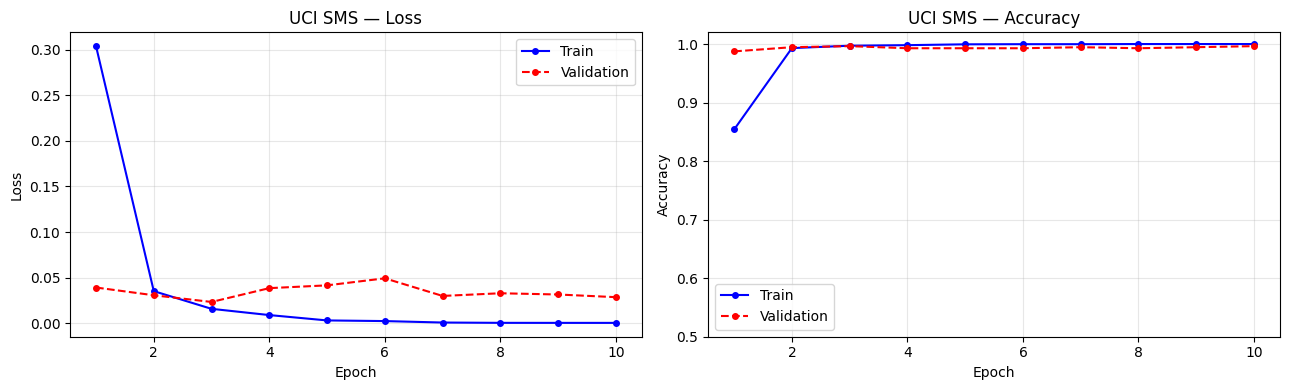

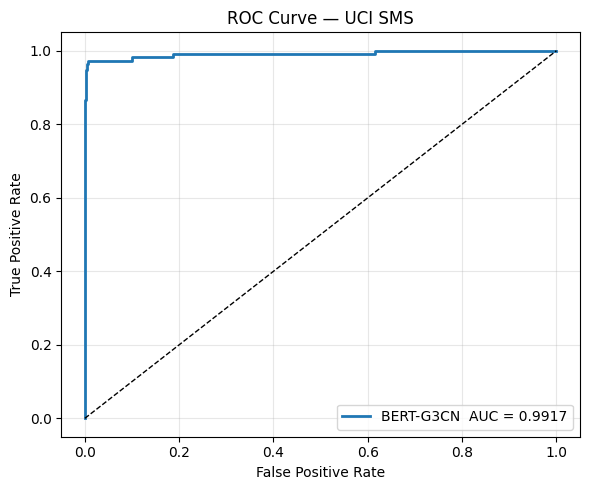

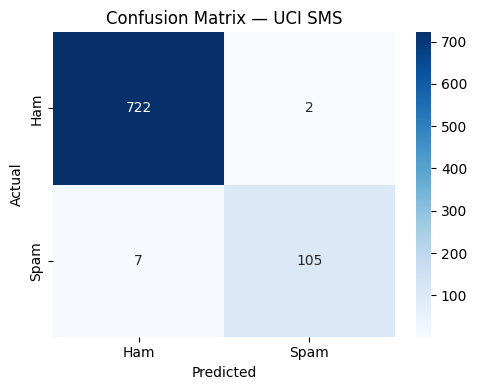

In [6]:
plot_training(result_uci)
plot_roc(result_uci)
plot_confusion(result_uci) 

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 5 — UCI SMS : Grid Search  (Tables 3, 4, 5)                ║
# ╚══════════════════════════════════════════════════════════════════╝

GS_EPOCHS = 10  

GRID = {
    "gcn_depth" : [1, 2, 3, 4],
    "dropout"   : [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], 
    "lr"        : [1e-4, 5e-5, 2e-5, 1e-5, 5e-6, 1e-6], 
}
 
PAPER = {
    "gcn_depth" : {1:99.28, 2:96.64, 3:97.20, 4:95.40},
    "dropout"   : {0.2:97.76, 0.3:95.62, 0.4:98.67, 0.5:99.28,
                   0.6:97.52, 0.7:96.78, 0.8:86.64},
    "lr"        : {1e-4:88.55, 5e-5:98.39, 2e-5:97.98, 1e-5:99.28,
                   5e-6:94.21, 1e-6:96.53},
}

BASE = {**UCI_CFG, "epochs": GS_EPOCHS}

gs_uci = {}

# ── Table 3 : GCN Depth ───────────────────────────────────────────
print("Table 3 — GCN depth  (other params fixed at best values)")
print(f"  {'Depth':>6}  {'Accuracy':>10}  {'AUC':>8}  {'Paper':>8}")  
print(f"  {'─'*40}")
gs_uci["gcn_depth"] = []
for d in GRID["gcn_depth"]:
    acc, auc = gs_trial(
        tr_uci, tr_l_uci, va_uci, va_l_uci, te_uci, te_l_uci,
        tok_uci, A_co_uci, A_het_uci, A_syn_uci, H_vocab_uci,
        **{**BASE, "gcn_depth": d})
    mark = "  ◀" if d == 1 else ""
    print(f"  {d:>6}  {acc:>10.2f}  {auc:>8.4f}  "
          f"{PAPER['gcn_depth'][d]:>8.2f}{mark}")
    gs_uci["gcn_depth"].append((d, acc, auc))



Table 3 — GCN depth  (other params fixed at best values)
   Depth    Accuracy       AUC     Paper
  ────────────────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       1       98.92    0.9917     99.28  ◀


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       2       99.04    0.9913     96.64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       3       99.04    0.9901     97.20


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       4       99.04    0.9904     95.40


In [8]:
# ── Table 4 : Dropout ─────────────────────────────────────────────
print("\nTable 4 — Dropout rate  (depth=1, lr=1e-5)")
print(f"  {'Dropout':>8}  {'Accuracy':>10}  {'AUC':>8}  {'Paper':>8}")
print(f"  {'─'*42}")
gs_uci["dropout"] = []
for dr in GRID["dropout"]:
    acc, auc = gs_trial(
        tr_uci, tr_l_uci, va_uci, va_l_uci, te_uci, te_l_uci,  
        tok_uci, A_co_uci, A_het_uci, A_syn_uci, H_vocab_uci, 
        **{**BASE, "dropout": dr})
    mark = "  ◀" if dr == 0.5 else ""
    print(f"  {dr:>8}  {acc:>10.2f}  {auc:>8.4f}  "
          f"{PAPER['dropout'][dr]:>8.2f}{mark}")
    gs_uci["dropout"].append((dr, acc, auc))




Table 4 — Dropout rate  (depth=1, lr=1e-5)
   Dropout    Accuracy       AUC     Paper
  ──────────────────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       0.2       98.80    0.9945     97.76


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       0.3       99.16    0.9920     95.62


...

       0.6       99.04    0.9939     97.52


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       0.7       99.16    0.9925     96.78


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       0.8       99.04    0.9919     86.64


In [9]:
# ── Table 5 : Learning Rate ───────────────────────────────────────
print("\nTable 5 — Learning rate  (depth=1, dropout=0.5)")
lr_labels = ["1e-4", "5e-5", "2e-5", "1e-5", "5e-6", "1e-6"]
print(f"  {'LR':>8}  {'Accuracy':>10}  {'AUC':>8}  {'Paper':>8}")
print(f"  {'─'*42}")
gs_uci["lr"] = []
for lr, lbl in zip(GRID["lr"], lr_labels):
    acc, auc = gs_trial(
        tr_uci, tr_l_uci, va_uci, va_l_uci, te_uci, te_l_uci, 
        tok_uci, A_co_uci, A_het_uci, A_syn_uci, H_vocab_uci,
        **{**BASE, "lr": lr})
    mark = "  ◀" if lr == 1e-5 else ""
    print(f"  {lbl:>8}  {acc:>10.2f}  {auc:>8.4f}  "
          f"{PAPER['lr'][lr]:>8.2f}{mark}")
    gs_uci["lr"].append((lbl, acc, auc))




Table 5 — Learning rate  (depth=1, dropout=0.5)
        LR    Accuracy       AUC     Paper
  ──────────────────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      1e-4       98.56    0.9949     88.55


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      5e-5       98.56    0.9899     98.39


...

      1e-5       98.92    0.9917     99.28  ◀


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      5e-6       98.92    0.9925     94.21


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      1e-6       98.56    0.9909     96.53


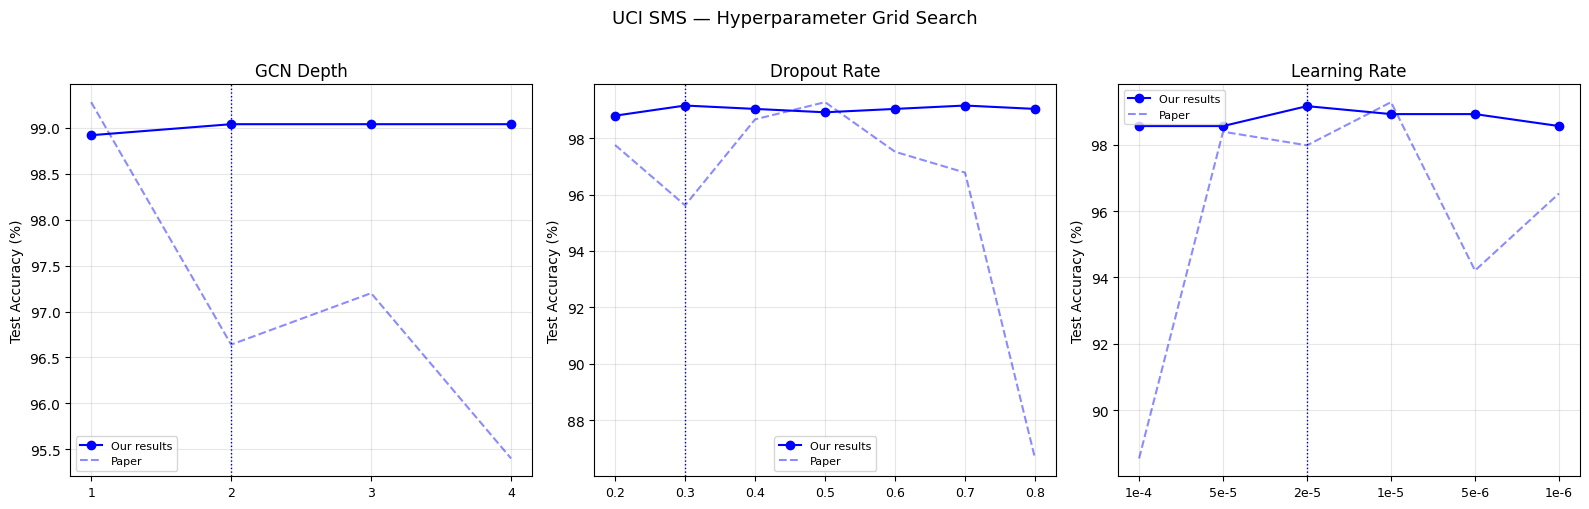


Optimal configuration: depth=1, dropout=0.5, lr=1e-5


In [10]:
# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, key, title, xlabels, paper_ref in [
    (axes[0], "gcn_depth", "GCN Depth",
     [str(v) for v in GRID["gcn_depth"]],
     list(PAPER["gcn_depth"].values())),
    (axes[1], "dropout",   "Dropout Rate",  
     [str(v) for v in GRID["dropout"]],
     list(PAPER["dropout"].values())),
    (axes[2], "lr",        "Learning Rate", 
     lr_labels,
     list(PAPER["lr"].values())),
]:
    ours = [r[1] for r in gs_uci[key]]
    x    = range(len(ours))
    ax.plot(x, ours,      "b-o", ms=6, label="Our results")
    ax.plot(x, paper_ref, "b--", ms=4, alpha=0.45, label="Paper")
    ax.set_xticks(list(x)); ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(title); ax.set_ylabel("Test Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
    ax.axvline(int(np.argmax(ours)), color="navy", lw=1, linestyle=":")

plt.suptitle("UCI SMS — Hyperparameter Grid Search", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("\nOptimal configuration: depth=1, dropout=0.5, lr=1e-5")

In [11]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 6 — ExAIS SMS : Training & Evaluation                     ║
# ║  Paper target: Accuracy 93.78%  |  AUC 0.9784                  ║
# ╚══════════════════════════════════════════════════════════════════╝

EXAIS_CFG = dict(
    bert_name    = "bert-base-uncased",
    epochs       = 10,
    batch_size   = 16,
    lr           = 1e-5,
    weight_decay = 1e-4,
    dropout      = 0.5,
    gcn_depth    = 1,
    max_len      = 128,
)

# ── Vocabulary ────────────────────────────────────────────────────
print("Building vocabulary ...")
vocab_ex = build_vocabulary(tr_ex)
print(f"  {len(vocab_ex):,} unique words (min frequency = 2)\n")

# ── Graphs ────────────────────────────────────────────────────────
print("Constructing graphs (built once, reused for all ExAIS experiments) ...")
t0 = time.time()
A_co_ex, A_het_ex, A_syn_ex = build_all_graphs(tr_ex, vocab_ex)
print(f"  Done in {time.time()-t0:.0f}s\n")

# ── Tokeniser + vocab embeddings ─────────────────────────────────
print("Preparing tokeniser and vocabulary embeddings ...")
tok_ex     = BertTokenizer.from_pretrained(EXAIS_CFG["bert_name"])
_tmp       = BertModel.from_pretrained(EXAIS_CFG["bert_name"], 
                 ignore_mismatched_sizes=True).to(DEVICE)
H_vocab_ex = build_vocab_embeddings(vocab_ex, _tmp, tok_ex)
del _tmp; gc.collect(); torch.cuda.empty_cache()
print(f"  Embedding matrix: {H_vocab_ex.shape}\n")

# ── DataLoaders ───────────────────────────────────────────────────
tr_loader_ex, va_loader_ex, te_loader_ex = make_loaders(
    tr_ex, tr_l_ex, va_ex, va_l_ex, te_ex, te_l_ex,
    tok_ex, EXAIS_CFG["max_len"], EXAIS_CFG["batch_size"])

# ── Training ──────────────────────────────────────────────────────
print(f"Training on ExAIS SMS  —  {EXAIS_CFG['epochs']} epochs, "
      f"lr={EXAIS_CFG['lr']}, dropout={EXAIS_CFG['dropout']}")

result_ex = train_model(
    name      = "ExAIS SMS",
    tr_loader = tr_loader_ex,
    va_loader = va_loader_ex,
    te_loader = te_loader_ex,
    A_co      = A_co_ex,
    A_het     = A_het_ex,
    A_syn     = A_syn_ex,
    H_vocab   = H_vocab_ex,
    **EXAIS_CFG,
)

# ── Results ───────────────────────────────────────────────────────
print_metrics(result_ex, paper_acc="93.78", paper_auc="0.9784")
print()
print(classification_report(result_ex["true"], result_ex["preds"],
                             target_names=["Ham", "Spam"]))


Building vocabulary ...
  5,042 unique words (min frequency = 2)

Constructing graphs (built once, reused for all ExAIS experiments) ...


  Done in 137s

Preparing tokeniser and vocabulary embeddings ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Embedding matrix: torch.Size([5042, 768])

Training on ExAIS SMS  —  10 epochs, lr=1e-05, dropout=0.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

      7     0.0870    0.9709     0.3289    0.9237  106.9s  ◀


      8     0.0693    0.9749     0.3570    0.9076  107.0s


      9     0.0678    0.9764     0.3392    0.9157  106.6s


     10     0.0563    0.9794     0.3511    0.9116  106.5s



  Results — ExAIS SMS
  ────────────────────────────────────────────────────
  Class     Precision     Recall   F1-Score
  Ham          0.9460     0.9359     0.9410
  Spam         0.9186     0.9312     0.9248
  ────────────────────────────────────────────────────
  Accuracy : 93.39%   (paper: 93.78%)
  AUC      : 0.9806   (paper: 0.9784)

              precision    recall  f1-score   support

         Ham       0.95      0.94      0.94       281
        Spam       0.92      0.93      0.92       218

    accuracy                           0.93       499
   macro avg       0.93      0.93      0.93       499
weighted avg       0.93      0.93      0.93       499



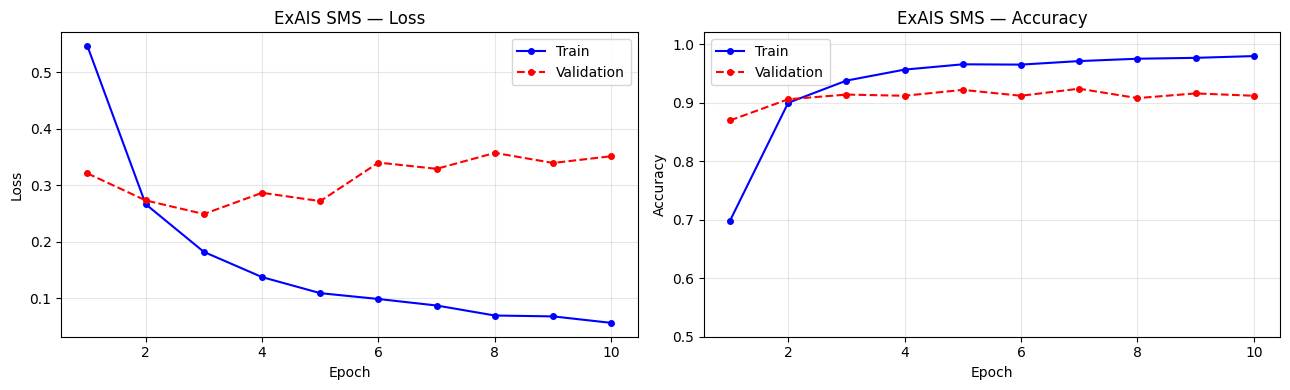

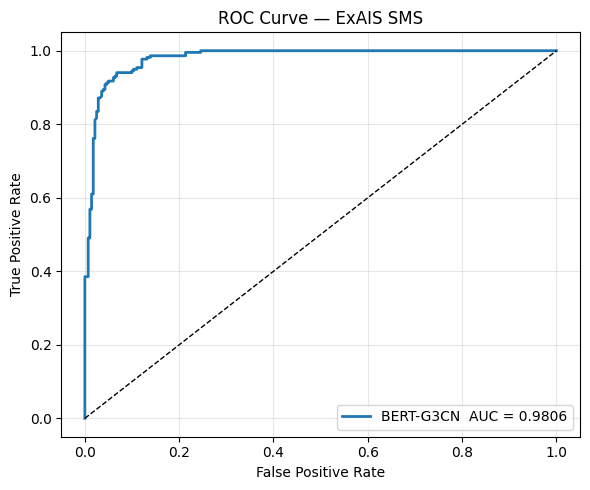

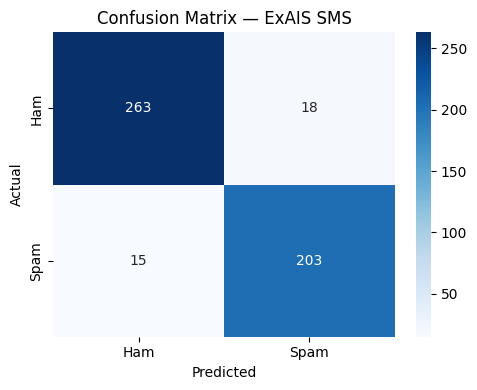

In [12]:
plot_training(result_ex)
plot_roc(result_ex)
plot_confusion(result_ex)

In [13]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 7 — ExAIS SMS : Grid Search  (Tables 3, 4, 5)             ║
# ╚══════════════════════════════════════════════════════════════════╝

GS_EPOCHS = 5

GRID = {
    "gcn_depth" : [1, 2, 3, 4],
    "dropout"   : [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "lr"        : [1e-4, 5e-5, 2e-5, 1e-5, 5e-6, 1e-6],
}

PAPER_EX = {
    "gcn_depth" : {1:93.78, 2:89.66, 3:87.79, 4:87.95},
    "dropout"   : {0.2:92.75, 0.3:89.46, 0.4:88.85, 0.5:93.78,
                   0.6:91.78, 0.7:90.09, 0.8:86.73},
    "lr"        : {1e-4:88.66, 5e-5:87.73, 2e-5:91.20, 1e-5:93.78,
                   5e-6:90.21, 1e-6:85.65},
}

BASE_EX = {**EXAIS_CFG, "epochs": GS_EPOCHS}
gs_ex   = {}

# ── Table 3 : GCN Depth ───────────────────────────────────────────
print("Table 3 — GCN depth  (other params fixed at best values)")
print(f"  {'Depth':>6}  {'Accuracy':>10}  {'AUC':>8}  {'Paper':>8}")
print(f"  {'─'*40}")
gs_ex["gcn_depth"] = []
for d in GRID["gcn_depth"]:
    acc, auc = gs_trial(
        tr_ex, tr_l_ex, va_ex, va_l_ex, te_ex, te_l_ex,
        tok_ex, A_co_ex, A_het_ex, A_syn_ex, H_vocab_ex,
        **{**BASE_EX, "gcn_depth": d})
    mark = "  ◀" if d == 1 else ""
    print(f"  {d:>6}  {acc:>10.2f}  {auc:>8.4f}  "
          f"{PAPER_EX['gcn_depth'][d]:>8.2f}{mark}")
    gs_ex["gcn_depth"].append((d, acc, auc))



Table 3 — GCN depth  (other params fixed at best values)
   Depth    Accuracy       AUC     Paper
  ────────────────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       1       93.19    0.9795     93.78  ◀


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       2       92.79    0.9791     89.66


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       3       92.18    0.9786     87.79


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       4       93.79    0.9821     87.95


In [14]:
# ── Table 4 : Dropout ─────────────────────────────────────────────
print("\nTable 4 — Dropout rate  (depth=1, lr=1e-5)")
print(f"  {'Dropout':>8}  {'Accuracy':>10}  {'AUC':>8}  {'Paper':>8}")
print(f"  {'─'*42}")
gs_ex["dropout"] = []
for dr in GRID["dropout"]:
    acc, auc = gs_trial(
        tr_ex, tr_l_ex, va_ex, va_l_ex, te_ex, te_l_ex,
        tok_ex, A_co_ex, A_het_ex, A_syn_ex, H_vocab_ex,
        **{**BASE_EX, "dropout": dr})
    mark = "  ◀" if dr == 0.5 else ""
    print(f"  {dr:>8}  {acc:>10.2f}  {auc:>8.4f}  "
          f"{PAPER_EX['dropout'][dr]:>8.2f}{mark}")
    gs_ex["dropout"].append((dr, acc, auc))




Table 4 — Dropout rate  (depth=1, lr=1e-5)
   Dropout    Accuracy       AUC     Paper
  ──────────────────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       0.2       93.19    0.9801     92.75


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       0.3       93.19    0.9804     89.46


...

       0.6       92.59    0.9787     91.78


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       0.7       92.99    0.9805     90.09


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

       0.8       92.59    0.9799     86.73


In [15]:
# ── Table 5 : Learning Rate ───────────────────────────────────────
lr_labels = ["1e-4", "5e-5", "2e-5", "1e-5", "5e-6", "1e-6"]
print("\nTable 5 — Learning rate  (depth=1, dropout=0.5)")
print(f"  {'LR':>8}  {'Accuracy':>10}  {'AUC':>8}  {'Paper':>8}")
print(f"  {'─'*42}")
gs_ex["lr"] = []
for lr, lbl in zip(GRID["lr"], lr_labels):
    acc, auc = gs_trial(
        tr_ex, tr_l_ex, va_ex, va_l_ex, te_ex, te_l_ex,
        tok_ex, A_co_ex, A_het_ex, A_syn_ex, H_vocab_ex,
        **{**BASE_EX, "lr": lr})
    mark = "  ◀" if lr == 1e-5 else ""
    print(f"  {lbl:>8}  {acc:>10.2f}  {auc:>8.4f}  "
          f"{PAPER_EX['lr'][lr]:>8.2f}{mark}")
    gs_ex["lr"].append((lbl, acc, auc))




Table 5 — Learning rate  (depth=1, dropout=0.5)
        LR    Accuracy       AUC     Paper
  ──────────────────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      1e-4       93.39    0.9814     88.66


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      5e-5       93.79    0.9793     87.73


...

      1e-5       93.19    0.9795     93.78  ◀


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      5e-6       92.18    0.9779     90.21


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      1e-6       87.78    0.9340     85.65


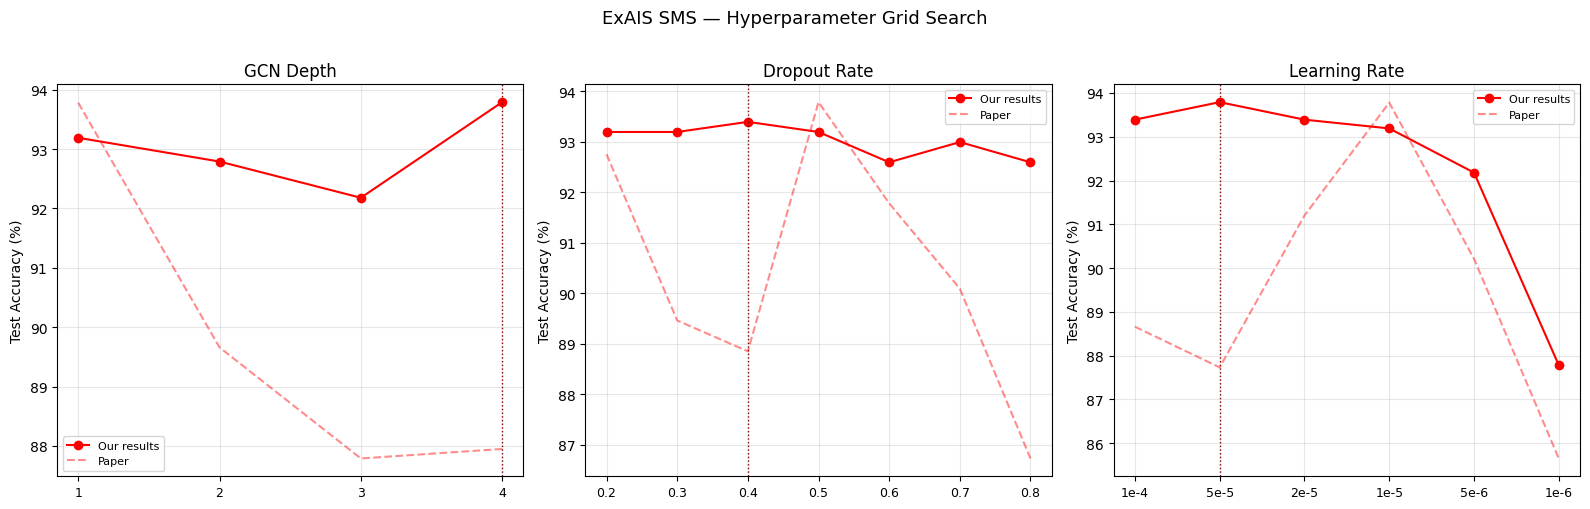


Optimal configuration: depth=1, dropout=0.5, lr=1e-5


In [16]:
# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, key, title, xlabels, paper_ref in [
    (axes[0], "gcn_depth", "GCN Depth",
     [str(v) for v in GRID["gcn_depth"]],
     list(PAPER_EX["gcn_depth"].values())),
    (axes[1], "dropout",   "Dropout Rate",
     [str(v) for v in GRID["dropout"]],
     list(PAPER_EX["dropout"].values())),
    (axes[2], "lr",        "Learning Rate",
     lr_labels,
     list(PAPER_EX["lr"].values())),
]:
    ours = [r[1] for r in gs_ex[key]]
    x    = range(len(ours))
    ax.plot(x, ours,      "r-o", ms=6, label="Our results")
    ax.plot(x, paper_ref, "r--", ms=4, alpha=0.45, label="Paper")
    ax.set_xticks(list(x)); ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(title); ax.set_ylabel("Test Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
    ax.axvline(int(np.argmax(ours)), color="darkred", lw=1, linestyle=":")

plt.suptitle("ExAIS SMS — Hyperparameter Grid Search", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("\nOptimal configuration: depth=1, dropout=0.5, lr=1e-5")

In [17]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 8 — Combined Results  (Both Datasets)                     ║
# ║  Requires result_uci (Cell 4) and result_ex (Cell 6).           ║
# ╚══════════════════════════════════════════════════════════════════╝

PAPER_TARGETS = {
    "UCI SMS"  : {"acc": 99.28, "auc": 0.9991,
                  "ham": (0.9928,0.9990,0.9959),
                  "spam":(0.9925,0.9500,0.9708)},
    "ExAIS SMS": {"acc": 93.78, "auc": 0.9784,
                  "ham": (0.9487,0.9384,0.9435),
                  "spam":(0.9244,0.9369,0.9306)},
}

# ── Table 7 : Performance metrics ────────────────────────────────
print("=" * 66)
print("  Table 7 & 8  —  BERT-G3CN on Both Datasets")
print("=" * 66)
print(f"  {'Dataset':<13} {'Class':<6} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8} {'Accuracy':>10}")
print(f"  {'─'*60}")

for res in [result_uci, result_ex]:
    ds = res["name"]
    p, r, f = res["precision"], res["recall"], res["f1"]
    pt = PAPER_TARGETS[ds]
    print(f"  {ds:<13} {'Ham':<6} {p[0]:>10.4f} {r[0]:>8.4f} {f[0]:>8.4f}"
          f" {res['te_acc']*100:>10.2f}%")
    print(f"  {'':<13} {'Spam':<6} {p[1]:>10.4f} {r[1]:>8.4f} {f[1]:>8.4f}")
    diff = res["te_acc"]*100 - pt["acc"]
    sign = "+" if diff >= 0 else ""
    print(f"  {'':<13} {'AUC':<6} {res['te_auc']:>10.4f}"
          f"   paper: acc={pt['acc']}%  auc={pt['auc']}"
          f"   ({sign}{diff:.2f}%)")
    print(f"  {'─'*60}")



  Table 7 & 8  —  BERT-G3CN on Both Datasets
  Dataset       Class   Precision   Recall       F1   Accuracy
  ────────────────────────────────────────────────────────────
  UCI SMS       Ham        0.9904   0.9972   0.9938      98.92%
                Spam       0.9813   0.9375   0.9589
                AUC        0.9917   paper: acc=99.28%  auc=0.9991   (-0.36%)
  ────────────────────────────────────────────────────────────
  ExAIS SMS     Ham        0.9460   0.9359   0.9410      93.39%
                Spam       0.9186   0.9312   0.9248
                AUC        0.9806   paper: acc=93.78%  auc=0.9784   (-0.39%)
  ────────────────────────────────────────────────────────────


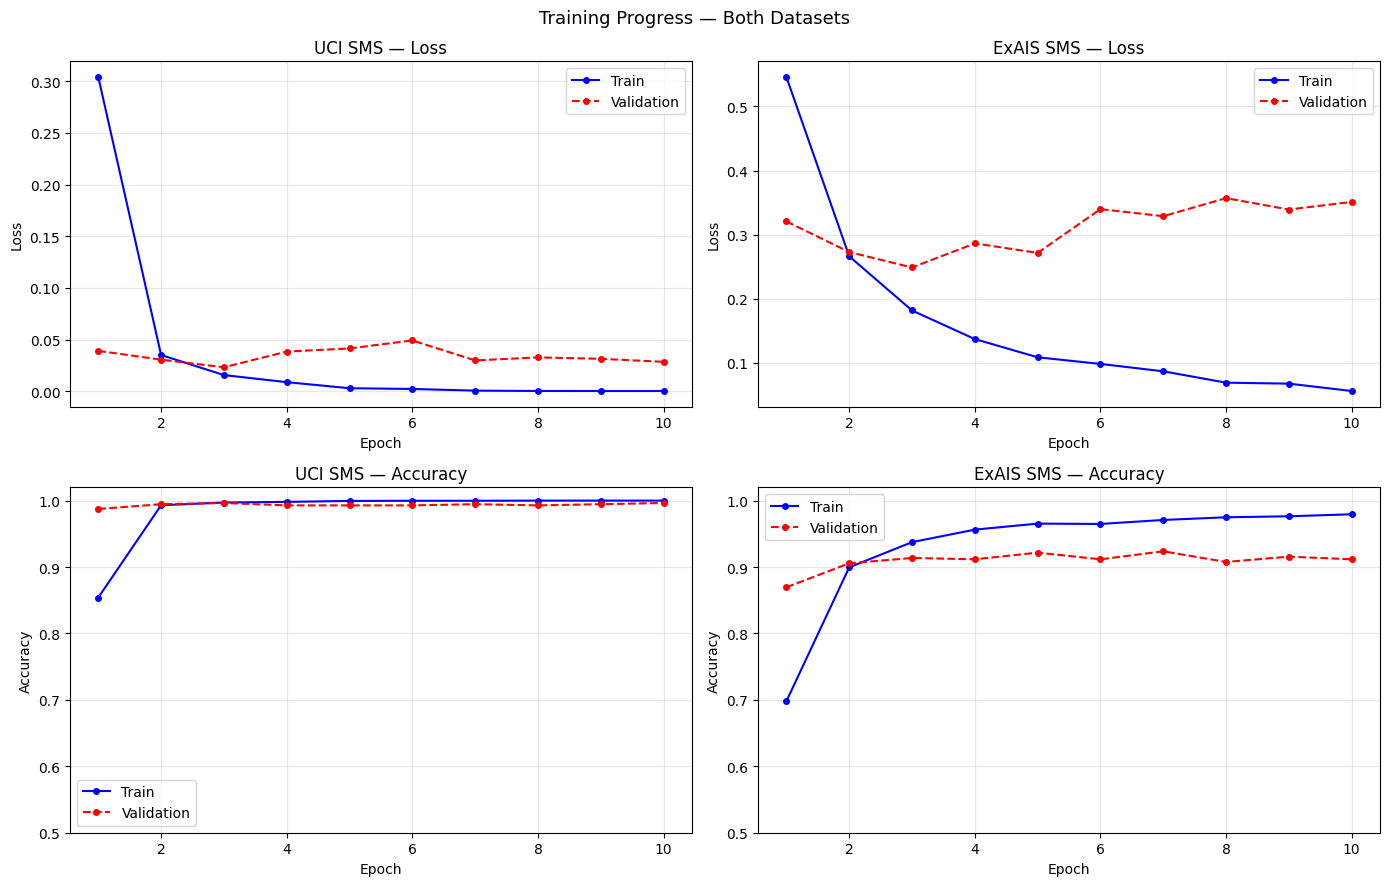

In [18]:
# ── Side-by-side training curves ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Training Progress — Both Datasets", fontsize=13)

for col, res in enumerate([result_uci, result_ex]):
    h  = res["history"]
    ep = range(1, len(h["tr_loss"]) + 1)
    axes[0,col].plot(ep, h["tr_loss"], "b-o", ms=4, label="Train")
    axes[0,col].plot(ep, h["va_loss"], "r--o", ms=4, label="Validation")
    axes[0,col].set(title=f"{res['name']} — Loss",
                    xlabel="Epoch", ylabel="Loss")
    axes[0,col].legend(); axes[0,col].grid(alpha=.3)

    axes[1,col].plot(ep, h["tr_acc"], "b-o", ms=4, label="Train")
    axes[1,col].plot(ep, h["va_acc"], "r--o", ms=4, label="Validation")
    axes[1,col].set(title=f"{res['name']} — Accuracy",
                    xlabel="Epoch", ylabel="Accuracy", ylim=(0.5, 1.02))
    axes[1,col].legend(); axes[1,col].grid(alpha=.3)

plt.tight_layout(); plt.show()



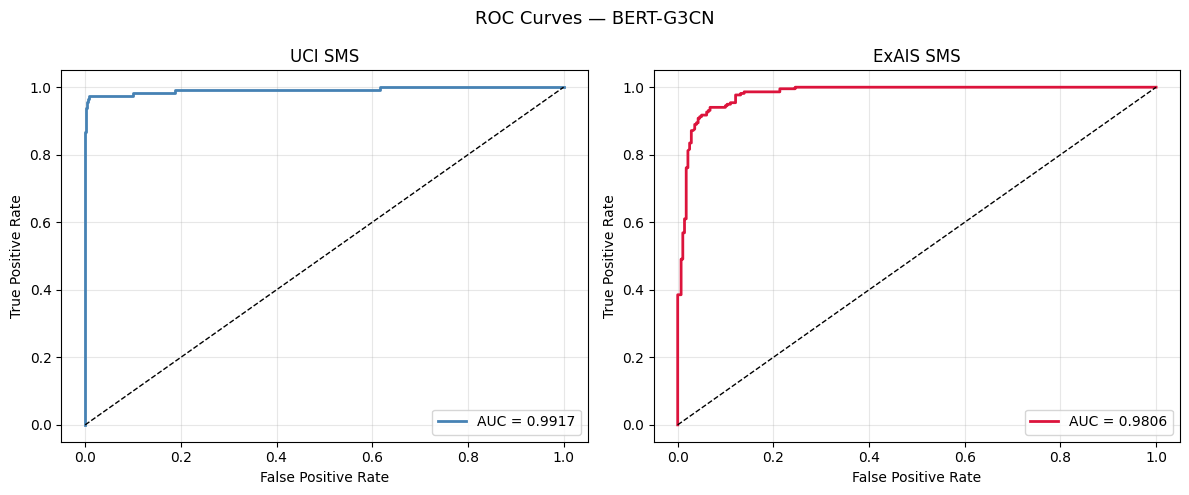

In [19]:
# ── Side-by-side ROC curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC Curves — BERT-G3CN", fontsize=13)

for ax, res, color in zip(axes, [result_uci, result_ex],
                           ["steelblue", "crimson"]):
    fpr, tpr, _ = roc_curve(res["true"], res["probs"])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"AUC = {res['te_auc']:.4f}")
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set(title=res["name"],
           xlabel="False Positive Rate",
           ylabel="True Positive Rate")
    ax.legend(); ax.grid(alpha=.3)

plt.tight_layout(); plt.show()



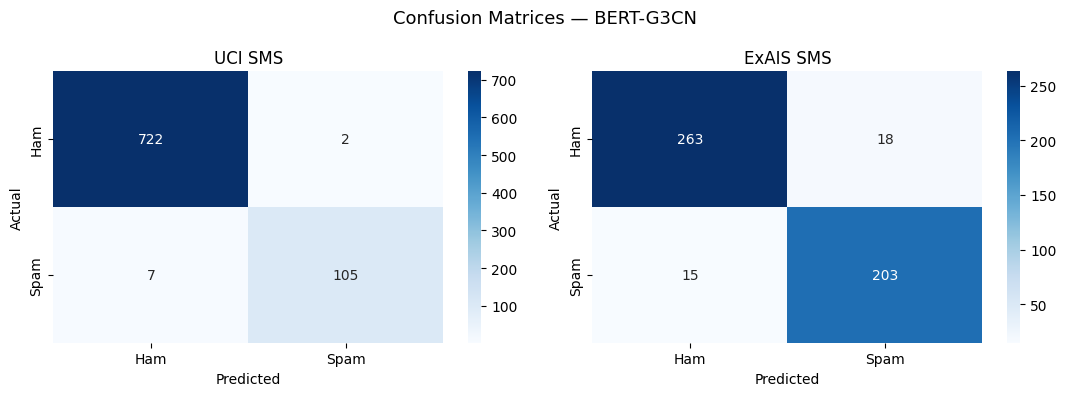

In [20]:
# ── Side-by-side confusion matrices ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Confusion Matrices — BERT-G3CN", fontsize=13)

for ax, res in zip(axes, [result_uci, result_ex]):
    cm = confusion_matrix(res["true"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, 
                xticklabels=["Ham","Spam"],
                yticklabels=["Ham","Spam"])
    ax.set(title=res["name"],
           xlabel="Predicted", ylabel="Actual")

plt.tight_layout(); plt.show()

In [21]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 9 — Ablation Study  (Table 9)                             ║
# ║  Removes one graph type at a time to measure each component's   ║
# ║  contribution.  Full-model rows reuse Cells 4 & 6.              ║
# ╚══════════════════════════════════════════════════════════════════╝

ABL_EPOCHS = 10

VARIANTS = [
    ("Full model",           ("co","het","syn")), 
    ("No co-occurrence",     ("het","syn")),
    ("No heterogeneous",     ("co","syn")),          
    ("No syntactic",         ("co","het")),   
]

PAPER_ABL = {
    "UCI SMS": {
        "Full model"      : (99.28, 0.9991),
        "No co-occurrence": (98.92, 0.9953),
        "No heterogeneous": (99.19, 0.9957), 
        "No syntactic"    : (98.83, 0.9932),
    },
    "ExAIS SMS": {
        "Full model"      : (93.78, 0.9784),
        "No co-occurrence": (87.96, 0.9699),
        "No heterogeneous": (91.98, 0.9754),
        "No syntactic"    : (92.58, 0.9763),
    },
}


def ablation_trial(label, graphs_on,
                    tr_txt, tr_lbl, va_txt, va_lbl, te_txt, te_lbl,
                    A_co_full, A_het_full, A_syn_full,
                    H_vocab, tokenizer, cfg):
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    A_co  = A_co_full .clone() if "co"  in graphs_on else torch.zeros_like(A_co_full)
    A_het = A_het_full.clone() if "het" in graphs_on else torch.zeros_like(A_het_full)
    A_syn = A_syn_full.clone() if "syn" in graphs_on else torch.zeros_like(A_syn_full)

    model = BERTG3CN(cfg["bert_name"],
                     dropout=cfg["dropout"],
                     gcn_depth=cfg["gcn_depth"]).to(DEVICE)

    tr_ld, va_ld, te_ld = make_loaders(
        tr_txt, tr_lbl, va_txt, va_lbl, te_txt, te_lbl,
        tokenizer, cfg["max_len"], cfg["batch_size"])

    opt   = AdamW(model.parameters(), lr=cfg["lr"],
                  weight_decay=cfg["weight_decay"])
    steps = len(tr_ld) * ABL_EPOCHS
    sched = get_linear_schedule_with_warmup(opt, int(0.1*steps), steps)
    crit  = nn.CrossEntropyLoss()

    best_va, best_st = 0.0, None
    for _ in range(ABL_EPOCHS):
        train_epoch(model, tr_ld, opt, sched, crit, A_co, A_het, A_syn, H_vocab)
        _, va, _, _, _ = eval_epoch(model, va_ld, crit, A_co, A_het, A_syn, H_vocab)
        if va > best_va:
            best_va = va
            best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_st.items()})
    _, acc, preds, probs, true = eval_epoch(
        model, te_ld, crit, A_co, A_het, A_syn, H_vocab)
    p, r, f, _ = precision_recall_fscore_support(
        true, preds, average=None, labels=[0,1])
    auc = roc_auc_score(true, probs)
    del model; gc.collect(); torch.cuda.empty_cache()
    return round(acc*100, 2), round(auc, 4), p, r, f


def run_ablation(ds_name, result_full, cfg,
                  tr_txt, tr_lbl, va_txt, va_lbl, te_txt, te_lbl,
                  A_co_full, A_het_full, A_syn_full, H_vocab, tokenizer):
    print(f"\nAblation — {ds_name}  ({ABL_EPOCHS} epochs each)")
    records = []
    for label, graphs in VARIANTS:
        if label == "Full model":
            acc = round(result_full["te_acc"]*100, 2)
            auc = round(result_full["te_auc"], 4)
            p, r, f = result_full["precision"], result_full["recall"], result_full["f1"]
            print(f"  {label:<22}  reusing trained model")
        else:
            print(f"  Training: {label} ...")
            acc, auc, p, r, f = ablation_trial(
                label, graphs,
                tr_txt, tr_lbl, va_txt, va_lbl, te_txt, te_lbl,
                A_co_full, A_het_full, A_syn_full, H_vocab, tokenizer, cfg)
        records.append(dict(label=label, acc=acc, auc=auc, p=p, r=r, f=f))
    return records


# ── Run on both datasets ──────────────────────────────────────────
abl_uci = run_ablation("UCI SMS",   result_uci, UCI_CFG,
                        tr_uci, tr_l_uci, va_uci, va_l_uci,
                        te_uci, te_l_uci,
                        A_co_uci, A_het_uci, A_syn_uci,
                        H_vocab_uci, tok_uci)

abl_ex  = run_ablation("ExAIS SMS", result_ex,  EXAIS_CFG,
                        tr_ex,  tr_l_ex,  va_ex,  va_l_ex,
                        te_ex,  te_l_ex,
                        A_co_ex, A_het_ex, A_syn_ex,
                        H_vocab_ex, tok_ex)

# ── Table 9 ───────────────────────────────────────────────────────
print("\n" + "=" * 68)
print("  Table 9  —  Ablation Study Results")
print("=" * 68)

for ds_name, records in [("UCI SMS", abl_uci), ("ExAIS SMS", abl_ex)]:
    full_acc = records[0]["acc"]
    print(f"\n  {ds_name}")
    print(f"  {'Variant':<22} {'Acc%':>8} {'Delta':>7} "
          f"{'AUC':>8} {'Paper Acc':>10}")
    print(f"  {'─'*60}")
    for rec in records:
        delta = rec["acc"] - full_acc
        sign  = f"+{delta:.2f}" if delta >= 0 else f"{delta:.2f}"
        pa    = PAPER_ABL[ds_name].get(rec["label"], (None,None))[0]
        ps    = f"{pa:.2f}" if pa else "—"
        print(f"  {rec['label']:<22} {rec['acc']:>8.2f} {sign:>7} "
              f"{rec['auc']:>8.4f} {ps:>10}")




Ablation — UCI SMS  (10 epochs each)
  Full model              reusing trained model
  Training: No co-occurrence ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Training: No heterogeneous ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Training: No syntactic ...


...

  Training: No heterogeneous ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Training: No syntactic ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


  Table 9  —  Ablation Study Results

  UCI SMS
  Variant                    Acc%   Delta      AUC  Paper Acc
  ────────────────────────────────────────────────────────────
  Full model                98.92   +0.00   0.9917      99.28
  No co-occurrence          99.04   +0.12   0.9907      98.92
  No heterogeneous          98.92   +0.00   0.9901      99.19
  No syntactic              99.04   +0.12   0.9939      98.83

  ExAIS SMS
  Variant                    Acc%   Delta      AUC  Paper Acc
  ────────────────────────────────────────────────────────────
  Full model                93.39   +0.00   0.9806      93.78
  No co-occurrence          92.38   -1.01   0.9800      87.96
  No heterogeneous          93.39   +0.00   0.9796      91.98
  No syntactic              93.79   +0.40   0.9810      92.58


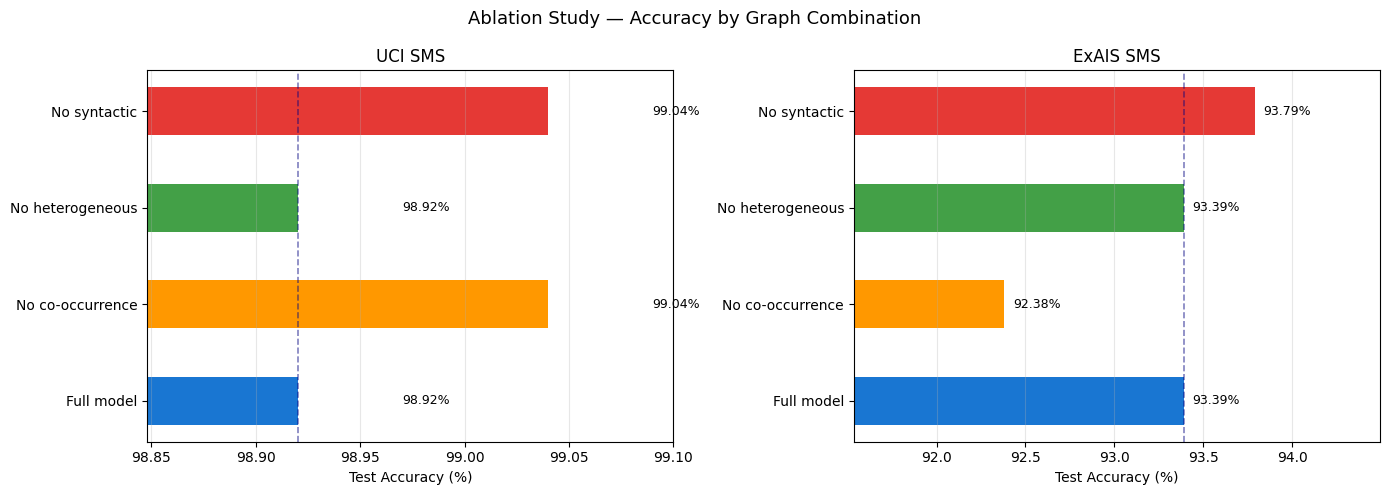

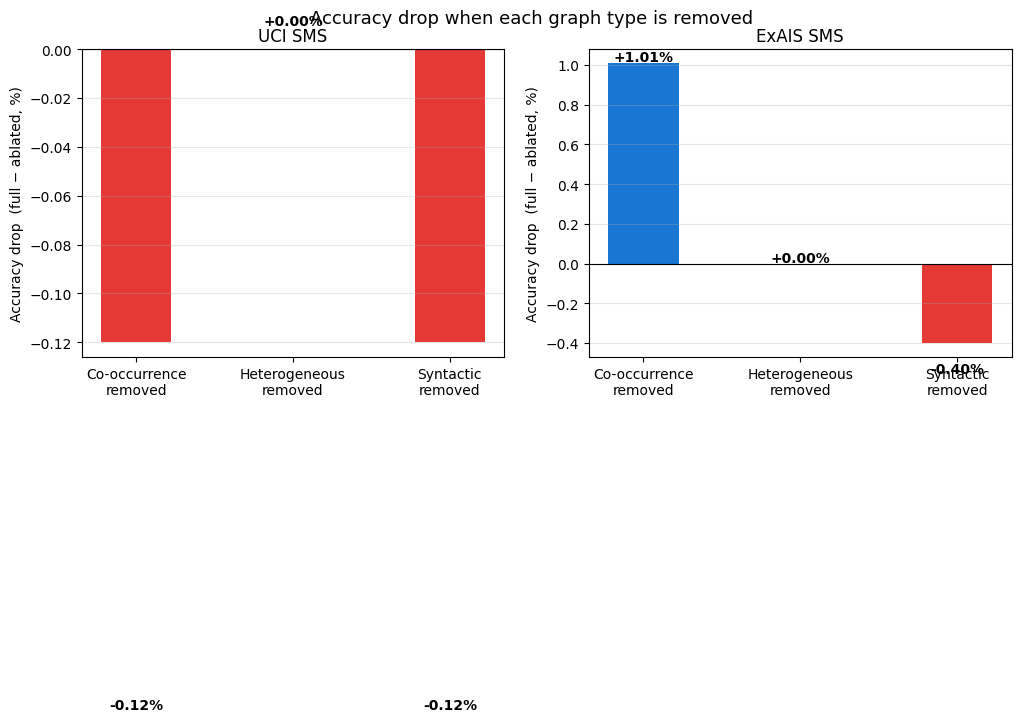

In [22]:
# ── Bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ablation Study — Accuracy by Graph Combination", fontsize=13)

palette = ["#1976D2","#FF9800","#43A047","#E53935"]

for ax, records, ds_name in [
    (axes[0], abl_uci, "UCI SMS"),
    (axes[1], abl_ex,  "ExAIS SMS"),
]:
    labels = [r["label"] for r in records]
    accs   = [r["acc"]   for r in records]
    bars   = ax.barh(labels, accs, color=palette, height=0.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_width() + 0.05,
                bar.get_y() + bar.get_height() / 2,
                f"{acc:.2f}%", va="center", fontsize=9)
    ax.axvline(accs[0], color="navy", lw=1.2, linestyle="--", alpha=0.5)
    span = max(accs) - min(accs)
    ax.set_xlim(min(accs) - span*0.6, max(accs) + span*0.5)
    ax.set_title(ds_name); ax.set_xlabel("Test Accuracy (%)")
    ax.grid(True, axis="x", alpha=.3)

plt.tight_layout(); plt.show()

# ── Delta chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Accuracy drop when each graph type is removed", fontsize=13)

for ax, records, ds_name in [
    (axes[0], abl_uci, "UCI SMS"),
    (axes[1], abl_ex,  "ExAIS SMS"),
]:
    full   = records[0]["acc"]
    names  = ["Co-occurrence\nremoved",
              "Heterogeneous\nremoved",
              "Syntactic\nremoved"]
    deltas = [full - records[i]["acc"] for i in range(1, 4)]
    colors = ["#1976D2" if d > 0 else "#E53935" for d in deltas]
    ax.bar(names, deltas, color=colors, width=0.45)
    for i, d in enumerate(deltas):
        ax.text(i, d + 0.01 if d >= 0 else d - 0.15,
                f"{d:+.2f}%", ha="center", fontsize=10, fontweight="bold")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(ds_name)
    ax.set_ylabel("Accuracy drop  (full − ablated, %)")
    ax.grid(True, axis="y", alpha=.3)

plt.tight_layout(); plt.show()

In [23]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 10 — Save Trained Models                                  ║
# ║  Run after Cells 4 & 6.  Saves everything needed for later      ║
# ║  inference — weights, vocabulary, graphs, config.               ║
# ╚══════════════════════════════════════════════════════════════════╝

def save_model_artifacts(result, vocab, A_co, A_het, A_syn, cfg, prefix):
    torch.save(
        {k: v.cpu() for k, v in result["model"].state_dict().items()},
        f"{prefix}_weights.pt")
    with open(f"{prefix}_vocab.json", "w") as fh:
        json.dump(vocab, fh)
    torch.save({"A_co": A_co.cpu(), "A_het": A_het.cpu(), "A_syn": A_syn.cpu()},
               f"{prefix}_graphs.pt")
    # store only json-serialisable values
    clean_cfg = {k: v for k, v in cfg.items() if isinstance(v, (str,int,float,bool))}
    with open(f"{prefix}_config.json", "w") as fh:
        json.dump(clean_cfg, fh, indent=2)

    sizes = {f: round(os.path.getsize(f)/1e6, 1)
             for f in [f"{prefix}_weights.pt", f"{prefix}_vocab.json",
                       f"{prefix}_graphs.pt",  f"{prefix}_config.json"]}
    print(f"  {prefix} — saved ({sizes})")


print("Saving models ...")
save_model_artifacts(result_uci, vocab_uci,
                     A_co_uci, A_het_uci, A_syn_uci,
                     UCI_CFG, "uci_model")
save_model_artifacts(result_ex, vocab_ex,
                     A_co_ex, A_het_ex, A_syn_ex,
                     EXAIS_CFG, "exais_model")

print("\nFiles saved to the working directory.")
print("Download from Kaggle output tab or run:")
print("  from kaggle_secrets import UserSecretsClient  # or just find in /kaggle/working/")



Saving models ...
  uci_model — saved ({'uci_model_weights.pt': 442.0, 'uci_model_vocab.json': 0.1, 'uci_model_graphs.pt': 158.6, 'uci_model_config.json': 0.0})
  exais_model — saved ({'exais_model_weights.pt': 442.0, 'exais_model_vocab.json': 0.1, 'exais_model_graphs.pt': 305.1, 'exais_model_config.json': 0.0})

Files saved to the working directory.
Download from Kaggle output tab or run:
  from kaggle_secrets import UserSecretsClient  # or just find in /kaggle/working/


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Cell 11 — Load Model & Run Predictions                         ║
# ║  Can run in a completely fresh session.                         ║
# ║  Set PREFIX to "uci_model" or "exais_model".                   ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Configuration ─────────────────────────────────────────────────
PREFIX   = "uci_model"    # change to "exais_model" for the other model
MAX_LEN  = 128

# ── Load artifacts ────────────────────────────────────────────────
print(f"\nLoading {PREFIX} ...")

with open(f"{PREFIX}_config.json") as fh:
    _cfg = json.load(fh)

with open(f"{PREFIX}_vocab.json") as fh:
    _vocab = json.load(fh)

_graphs   = torch.load(f"{PREFIX}_graphs.pt", map_location=DEVICE)
_A_co     = _graphs["A_co"] .to(DEVICE)
_A_het    = _graphs["A_het"].to(DEVICE)
_A_syn    = _graphs["A_syn"].to(DEVICE)

_tokenizer = BertTokenizer.from_pretrained(_cfg["bert_name"])

_model = BERTG3CN(
    bert_name  = _cfg["bert_name"],
    dropout    = _cfg["dropout"],
    gcn_depth  = _cfg["gcn_depth"],
).to(DEVICE)
_model.load_state_dict(
    torch.load(f"{PREFIX}_weights.pt", map_location=DEVICE))
_model.eval()

# Build vocabulary embedding matrix for inference
print("Preparing vocabulary embeddings ...")
_H_vocab = build_vocab_embeddings(_vocab, _model.bert, _tokenizer)

print(f"  Ready.  Model trained on "
      f"{'UCI SMS' if 'uci' in PREFIX else 'ExAIS SMS'}, "
      f"vocab size = {len(_vocab):,}")


# ── Prediction function ───────────────────────────────────────────

@torch.no_grad()
def predict(messages): 
    """
    Pass a single string or a list of strings.
    Returns a list of dicts: message, label, spam_prob, ham_prob, confidence.
    """
    if isinstance(messages, str):
        messages = [messages]

    enc = _tokenizer(messages, max_length=MAX_LEN, padding="max_length",
                     truncation=True, return_tensors="pt")
    ids  = enc["input_ids"]     .to(DEVICE)
    mask = enc["attention_mask"].to(DEVICE)
    probs = F.softmax(
        _model(ids, mask, _A_co, _A_het, _A_syn, _H_vocab), dim=-1
    ).cpu().numpy()

    out = []
    for msg, p in zip(messages, probs):
        out.append({ 
            "message"   : msg,
            "label"     : "SPAM" if p[1] > p[0] else "HAM",
            "spam_prob" : round(float(p[1]) * 100, 2),
            "ham_prob"  : round(float(p[0]) * 100, 2),
            "confidence": round(float(max(p)) * 100, 2),
        })
    return out


def show_predictions(results):
    print(f"\n  {'#':<3} {'Label':<5}  {'Conf':>6}  {'Spam%':>6}  "
          f"{'Ham%':>6}  Message")
    print(f"  {'─'*80}")
    for i, r in enumerate(results, 1):
        tag = "SPAM" if r["label"] == "SPAM" else "HAM "
        msg = r["message"][:60] + "..." if len(r["message"]) > 60 else r["message"]
        print(f"  {i:<3} {tag}  {r['confidence']:>5.1f}%  "
              f"{r['spam_prob']:>5.1f}%  {r['ham_prob']:>5.1f}%  {msg}")


# ── Demo predictions ──────────────────────────────────────────────
DEMO_MESSAGES = [
    # Spam examples
    "WINNER!! You have been selected for a £1000 cash prize. Call now!",
    "FREE entry: Win a brand new iPhone. Text WIN to 80800. T&Cs apply.",
    "Urgent: Your account has been suspended. Verify at secure-login.net",  
    "Congratulations! You've won a free holiday. Click here to claim.",
    "Your mobile number has won £500. Reply YES to claim your reward.",
    # Ham examples
    "Hey, are you coming to the meeting at 3pm?",
    "I'll be home by 7, can you start dinner?",
    "Happy birthday! Hope you have a wonderful day.",
    "The report is ready, I've sent it over to you.",
    "Can we reschedule our call to tomorrow morning?",
    # Borderline
    "Your parcel could not be delivered. Click here to reschedule.",
    "Reminder: Your appointment is confirmed for Monday at 10am.",
    "We have a special offer just for you this weekend.",
]

print("\nRunning predictions on example messages ...")
show_predictions(predict(DEMO_MESSAGES))


# ── Interactive mode ──────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Interactive prediction  —  type any SMS message.")
print("  Enter 'quit' to exit.")
print("─" * 62)

while True:
    user_msg = input("\n  SMS: ").strip()
    if user_msg.lower() in ("quit", "exit", "q", ""):
        print("  Exiting.")
        break
    r = predict(user_msg)[0]
    print(f"\n  Prediction  : {r['label']}")
    print(f"  Spam        : {r['spam_prob']}%")
    print(f"  Ham         : {r['ham_prob']}%")
    print(f"  Confidence  : {r['confidence']}%")


Loading uci_model ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Preparing vocabulary embeddings ...
  Ready.  Model trained on UCI SMS, vocab size = 3,635

Running predictions on example messages ...

  #   Label    Conf   Spam%    Ham%  Message
  ────────────────────────────────────────────────────────────────────────────────
  1   SPAM   99.6%   99.6%    0.4%  WINNER!! You have been selected for a £1000 cash prize. Call...
  2   SPAM   99.8%   99.8%    0.2%  FREE entry: Win a brand new iPhone. Text WIN to 80800. T&Cs ...
  3   SPAM   98.5%   98.5%    1.5%  Urgent: Your account has been suspended. Verify at secure-lo...
  4   SPAM   99.1%   99.1%    0.9%  Congratulations! You've won a free holiday. Click here to cl...
  5   SPAM   99.6%   99.6%    0.4%  Your mobile number has won £500. Reply YES to claim your rew...
  6   HAM    99.9%    0.1%   99.9%  Hey, are you coming to the meeting at 3pm?
  7   HAM   100.0%    0.1%  100.0%  I'll be home by 7, can you start dinner?
  8   HAM    99.9%    0.1%   99.9%  Happy birthday! Hope you have a wonderful d

StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.